# DAOD Data Sanity

Sanity checks for the Cityscapes -> Foggy Cityscapes DAOD dataset and wrapper compatibility.

In [3]:
from __future__ import annotations

from pathlib import Path
import sys
sys.path.append('../../')
from types import SimpleNamespace

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torch.utils.data import Subset

from src.data.daod_cityscapes import build_dataset
from src.data.wrappers import IdFilteredDataset, LabelRouterDataset, TwoViewDataset

cfg = SimpleNamespace(
    data=SimpleNamespace(
        root="/home/ljzhang/data/ins-seg/cityscapes",
        foggy_beta="0.02",
    )
)

datasets = {
    split: build_dataset(cfg, split, transform=None)
    for split in ["source_train", "source_val", "target_train", "target_val"]
}
datasets.keys()

dict_keys(['source_train', 'source_val', 'target_train', 'target_val'])

In [4]:
counts = {name: len(ds) for name, ds in datasets.items()}
counts

{'source_train': 2975,
 'source_val': 500,
 'target_train': 2975,
 'target_val': 500}

In [11]:
def first_nonempty(dataset):
    for idx in range(len(dataset)):
        if dataset[idx]["annotations"]:
            return idx
    raise RuntimeError("No sample with annotations found")


indices = {name: first_nonempty(ds) for name, ds in datasets.items()}
indices

{'source_train': 0, 'source_val': 0, 'target_train': 0, 'target_val': 0}

In [9]:
for name, idx in indices.items():
    sample = datasets[name][idx]
    assert Path(sample["file_name"]).exists()
    assert sample["sample_id"]
    assert isinstance(sample["annotations"], list)
    assert sample["height"] > 0 and sample["width"] > 0
print("basic sample checks passed")

basic sample checks passed


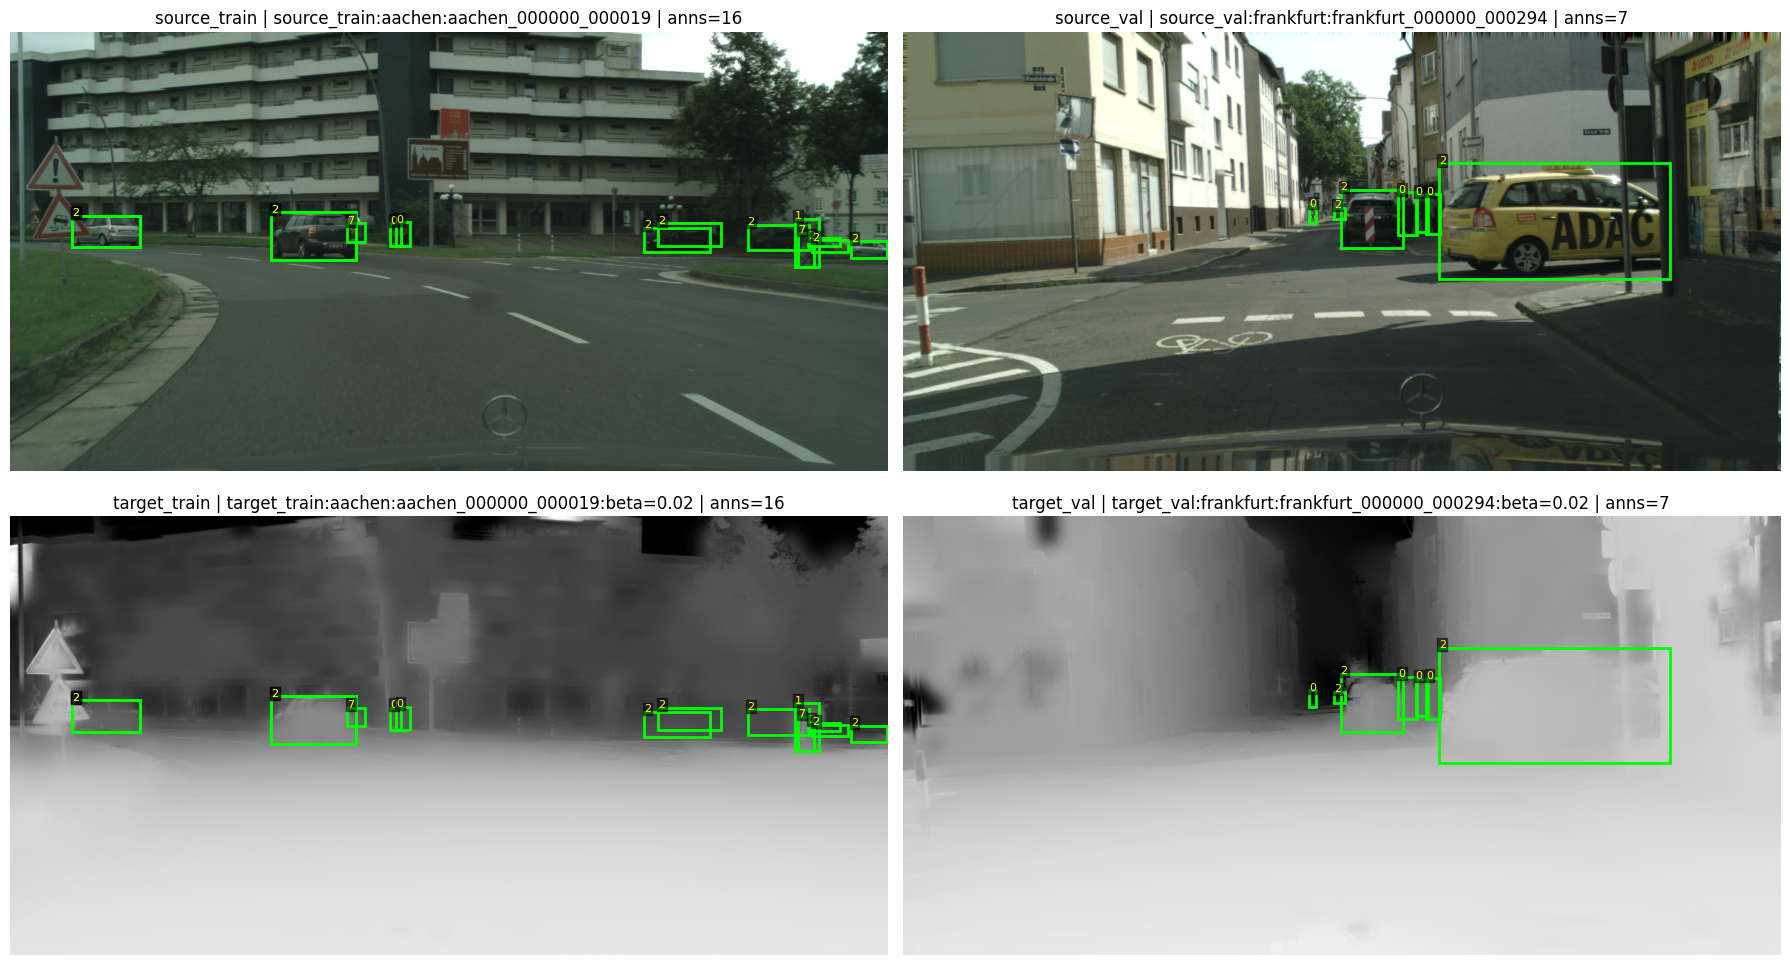

In [12]:
from PIL import Image

def draw_sample(sample, ax, title):
    image = Image.open(sample["file_name"]).convert("RGB")
    ax.imshow(image)
    for ann in sample["annotations"][:20]:
        x0, y0, x1, y1 = ann["bbox"]
        ax.add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0, linewidth=2, edgecolor="lime", facecolor="none"))
        ax.text(x0, y0, str(ann["category_id"]), color="yellow", fontsize=8, bbox={"facecolor": "black", "alpha": 0.5, "pad": 1})
    ax.set_title(title)
    ax.axis("off")


fig, axes = plt.subplots(2, 2, figsize=(18, 10))
for ax, (name, idx) in zip(axes.flatten(), indices.items()):
    sample = datasets[name][idx]
    draw_sample(sample, ax, f"{name} | {sample['sample_id']} | anns={len(sample['annotations'])}")
plt.tight_layout()

In [13]:
sample = datasets["target_train"][indices["target_train"]]
for ann in sample["annotations"]:
    x0, y0, x1, y1 = ann["bbox"]
    assert x0 < x1 and y0 < y1
    assert ann["area"] > 0
    assert ann["bbox_mode"] == 0
print("annotation checks passed")
sample["annotations"][:3]

annotation checks passed


[{'bbox': [609.0, 420.0, 807.0, 532.0],
  'bbox_mode': 0,
  'category_id': 2,
  'segmentation': [[806.0,
    503.0,
    803.0,
    524.0,
    796.0,
    528.0,
    785.0,
    528.0,
    778.0,
    527.0,
    776.0,
    520.0,
    771.0,
    520.0,
    768.0,
    515.0,
    732.0,
    515.0,
    728.0,
    523.0,
    722.0,
    523.0,
    715.0,
    524.0,
    714.0,
    523.0,
    711.0,
    520.0,
    709.0,
    517.0,
    706.0,
    517.0,
    702.0,
    520.0,
    697.0,
    529.0,
    690.0,
    532.0,
    681.0,
    532.0,
    678.0,
    529.0,
    674.0,
    527.0,
    671.0,
    517.0,
    635.0,
    514.0,
    632.0,
    525.0,
    615.0,
    526.0,
    611.0,
    521.0,
    609.0,
    483.0,
    620.0,
    464.0,
    629.0,
    459.0,
    625.0,
    453.0,
    629.0,
    450.0,
    634.0,
    450.0,
    639.0,
    455.0,
    644.0,
    456.0,
    644.0,
    453.0,
    643.0,
    450.0,
    658.0,
    429.0,
    672.0,
    422.0,
    674.0,
    420.0,
    766.0,
    420.0,
    

In [14]:
sample_dict = datasets["source_val"][indices["source_val"]]
assert sample_dict["sample_id"] == datasets["source_val"][indices["source_val"]]["sample_id"]
assert {"file_name", "image_id", "height", "width", "annotations", "sample_id"}.issubset(sample_dict.keys())
sample_dict

{'sample_id': 'source_val:frankfurt:frankfurt_000000_000294',
 'file_name': '/home/ljzhang/data/ins-seg/cityscapes/leftImg8bit/val/frankfurt/frankfurt_000000_000294_leftImg8bit.png',
 'image_id': 'source_val:frankfurt:frankfurt_000000_000294',
 'height': 1024,
 'width': 2048,
 'annotations': [{'bbox': [949.0, 406.0, 965.0, 445.0],
   'bbox_mode': 0,
   'category_id': 0,
   'segmentation': [[960.0,
     444.0,
     960.0,
     439.0,
     960.0,
     430.0,
     961.0,
     428.0,
     964.0,
     428.0,
     965.0,
     425.0,
     965.0,
     421.0,
     962.0,
     418.0,
     959.0,
     415.0,
     958.0,
     411.0,
     957.0,
     409.0,
     955.0,
     406.0,
     955.0,
     406.0,
     954.0,
     406.0,
     951.0,
     408.0,
     949.0,
     413.0,
     949.0,
     419.0,
     951.0,
     430.0,
     952.0,
     433.0,
     952.0,
     435.0,
     954.0,
     440.0,
     954.0,
     442.0,
     954.0,
     443.0,
     955.0,
     445.0,
     959.0,
     445.0]],
   'iscro

In [17]:
subset = Subset(datasets["target_train"], list(range(6)))
subset_items = [subset[i] for i in range(len(subset))]
queried_ids = {subset_items[0]["sample_id"], subset_items[1]["sample_id"]}
pseudo_store = {subset_items[2]["sample_id"]: [{"bbox": [0.0, 0.0, 1.0, 1.0], "bbox_mode": 0, "category_id": 0, "segmentation": [[0.0, 0.0, 1.0, 0.0, 1.0, 1.0]], "iscrowd": 0, "area": 1.0}]}

routed = LabelRouterDataset(subset, queried_ids=queried_ids, pseudo_store=pseudo_store, unlabeled_label=[])
labeled = IdFilteredDataset(routed, mode="labeled")
pseudo = IdFilteredDataset(routed, mode="pseudo")
pool = IdFilteredDataset(routed, mode="pool")
two_view = TwoViewDataset(
    labeled,
    weak_tf=lambda image: ("weak", image.size),
    strong_tf=lambda image: ("strong", image.size),
)

assert len(labeled) == 2
assert len(pseudo) == 1
assert len(pool) == 3
assert labeled[0]["sample_id"] in queried_ids
assert pseudo[0]["sample_id"] in pseudo_store
assert isinstance(pseudo[0]["annotations"], list)
assert pool[0]["annotations"] == []
tv = two_view[0]
assert tv["sample_id"] == labeled[0]["sample_id"]
assert tv["annotations"] == labeled[0]["annotations"]
print("wrapper compatibility checks passed")
tv

wrapper compatibility checks passed


{'x_w': ('weak', (2048, 1024)),
 'x_s': ('strong', (2048, 1024)),
 'annotations': [{'bbox': [609.0, 420.0, 807.0, 532.0],
   'bbox_mode': 0,
   'category_id': 2,
   'segmentation': [[806.0,
     503.0,
     803.0,
     524.0,
     796.0,
     528.0,
     785.0,
     528.0,
     778.0,
     527.0,
     776.0,
     520.0,
     771.0,
     520.0,
     768.0,
     515.0,
     732.0,
     515.0,
     728.0,
     523.0,
     722.0,
     523.0,
     715.0,
     524.0,
     714.0,
     523.0,
     711.0,
     520.0,
     709.0,
     517.0,
     706.0,
     517.0,
     702.0,
     520.0,
     697.0,
     529.0,
     690.0,
     532.0,
     681.0,
     532.0,
     678.0,
     529.0,
     674.0,
     527.0,
     671.0,
     517.0,
     635.0,
     514.0,
     632.0,
     525.0,
     615.0,
     526.0,
     611.0,
     521.0,
     609.0,
     483.0,
     620.0,
     464.0,
     629.0,
     459.0,
     625.0,
     453.0,
     629.0,
     450.0,
     634.0,
     450.0,
     639.0,
     455.0,
     6